In [ ]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install numpy pandas scikit-learn xgboost lightgbm catboost matplotlib seaborn

In [ ]:
!pip uninstall -y numpy pandas matplotlib seaborn
!pip install --no-cache-dir numpy pandas matplotlib seaborn
import os
os._exit(00)


Found existing installation: numpy 2.2.5
Uninstalling numpy-2.2.5:
  Successfully uninstalled numpy-2.2.5
Found existing installation: pandas 2.2.3
Uninstalling pandas-2.2.3:
  Successfully uninstalled pandas-2.2.3
Found existing installation: matplotlib 3.10.1
Uninstalling matplotlib-3.10.1:
  Successfully uninstalled matplotlib-3.10.1
Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Successfully uninstalled seaborn-0.13.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 82.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 210.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into accou

In [ ]:
get_ipython().run_line_magic('matplotlib', 'inline')
import os

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import random
import pickle

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import warnings
warnings.simplefilter("ignore")

In [ ]:
df=pd.read_csv(r"/content/drive/MyDrive/CTDAPD Dataset.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CTDAPD Dataset.csv'

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print(df.columns.tolist())

['Date', 'Source_IP', 'Destination_IP', 'Source_Port', 'Destination_Port', 'Protocol_Type', 'Flow_Duration', 'Packet_Size', 'Flow_Bytes_per_s', 'Flow_Packets_per_s', 'Total_Forward_Packets', 'Total_Backward_Packets', 'Packet_Length_Mean_Forward', 'Packet_Length_Mean_Backward', 'IAT_Forward', 'IAT_Backward', 'Active_Duration', 'Idle_Duration', 'IDS_Alert_Count', 'Anomaly_Score', 'Attack_Vector', 'Attack_Severity', 'Botnet_Family', 'Malware_Type', 'CPU_Utilization', 'Memory_Utilization', 'System_Patch_Status', 'Label', 'Normalized_Packet_Flow', 'Anomaly_Severity_Index']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54768 entries, 0 to 54767
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         54768 non-null  object 
 1   Source_IP                    54768 non-null  object 
 2   Destination_IP               54768 non-null  object 
 3   Source_Port                  54768 non-null  int64  
 4   Destination_Port             54768 non-null  int64  
 5   Protocol_Type                54768 non-null  object 
 6   Flow_Duration                54768 non-null  int64  
 7   Packet_Size                  54768 non-null  int64  
 8   Flow_Bytes_per_s             54768 non-null  float64
 9   Flow_Packets_per_s           54768 non-null  float64
 10  Total_Forward_Packets        54768 non-null  int64  
 11  Total_Backward_Packets       54768 non-null  int64  
 12  Packet_Length_Mean_Forward   54768 non-null  float64
 13  Packet_Length_Me

In [ ]:
df.isnull().sum()

,0
Date,0
Source_IP,0
Destination_IP,0
Source_Port,0
Destination_Port,0
Protocol_Type,0
Flow_Duration,0
Packet_Size,0
Flow_Bytes_per_s,0
Flow_Packets_per_s,0


In [ ]:
df=df.drop(columns=["Date","Attack_Vector","Botnet_Family","Malware_Type","Label"])
df

,Source_IP,Destination_IP,Source_Port,Destination_Port,Protocol_Type,Flow_Duration,Packet_Size,Flow_Bytes_per_s,Flow_Packets_per_s,Total_Forward_Packets,...,Active_Duration,Idle_Duration,IDS_Alert_Count,Anomaly_Score,Attack_Severity,CPU_Utilization,Memory_Utilization,System_Patch_Status,Normalized_Packet_Flow,Anomaly_Severity_Index
0,192.168.1.1,8.8.8.8,57708,443,TCP,15,500,6.375467,5.414037,19,...,30.111230,111.277671,2,41.692705,Low,16.375491,60.918547,Outdated,2.000000,73.168788
1,172.16.0.1,4.4.4.4,29980,8080,TCP,390,472,6.694334,2.497333,21,...,28.354223,108.347199,0,23.612143,Low,31.986167,7.718833,Outdated,0.102564,16.059524
2,10.0.0.1,8.8.8.8,31923,443,TCP,120,129,7.948582,3.607725,19,...,30.522506,123.483107,1,59.815946,Medium,1.919325,51.726672,Up-to-date,0.233333,99.333361
3,192.168.1.1,8.8.8.8,10525,80,TCP,3,500,7.326526,4.144272,24,...,38.444208,83.030309,1,34.907354,Low,21.078560,20.463289,Up-to-date,9.666667,46.645165
4,192.168.1.1,1.1.1.1,31755,80,UDP,7,458,7.080846,2.667007,15,...,32.243407,140.801780,0,42.164795,Medium,24.940597,43.652572,Up-to-date,3.571429,31.648643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54763,192.168.1.1,8.8.8.8,55784,80,ICMP,16,352,7.798953,2.326618,29,...,37.953122,97.660853,1,34.599529,Low,35.654680,57.471818,Up-to-date,2.562500,37.694837
54764,192.168.1.1,8.8.8.8,51055,80,TCP,0,649,5.104806,3.695383,15,...,32.632169,126.486955,0,48.929539,Medium,22.459519,34.834888,Up-to-date,inf,37.940200
54765,192.168.1.1,8.8.8.8,40203,443,TCP,200,848,13.540904,2.202821,19,...,28.136603,118.359130,3,28.744000,High,27.772790,10.906432,Outdated,0.145000,49.541831
54766,192.168.1.1,8.8.8.8,46248,8080,TCP,154,474,11.372500,2.262444,20,...,26.704507,98.153305,2,36.452310,Low,43.175241,25.847987,Up-to-date,0.253247,43.470523


In [ ]:
df.isnull().sum()

,0
Source_IP,0
Destination_IP,0
Source_Port,0
Destination_Port,0
Protocol_Type,0
Flow_Duration,0
Packet_Size,0
Flow_Bytes_per_s,0
Flow_Packets_per_s,0
Total_Forward_Packets,0


In [ ]:
df["Attack_Severity"].value_counts()

,count
Attack_Severity,
Low,33015
Medium,16414
High,5339


In [ ]:
from sklearn.utils import resample
# Separate majority and minority classes
df_majority = df[df['Attack_Severity']== "Low"]
df_minority = df[df['Attack_Severity']== "Medium"]
df_minority1 = df[df['Attack_Severity']== "High"]

# Downsample majority class and upsample the minority class
df_minority_upsampled = resample(df_minority, replace=True,n_samples=100000,random_state=100)
df_minority1_upsampled = resample(df_minority1, replace=True,n_samples=100000,random_state=100)
df_majority_downsampled = resample(df_majority, replace=True,n_samples=100000,random_state=100)

# Combine minority class with downsampled majority class
df_balanced = pd.concat([df_minority_upsampled,df_minority1_upsampled,df_majority_downsampled])

# Display new class counts
df_balanced['Attack_Severity'].value_counts()

,count
Attack_Severity,
Medium,100000
High,100000
Low,100000


In [ ]:
df = df_balanced

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 19275 to 2106
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Source_IP                    300000 non-null  object 
 1   Destination_IP               300000 non-null  object 
 2   Source_Port                  300000 non-null  int64  
 3   Destination_Port             300000 non-null  int64  
 4   Protocol_Type                300000 non-null  object 
 5   Flow_Duration                300000 non-null  int64  
 6   Packet_Size                  300000 non-null  int64  
 7   Flow_Bytes_per_s             300000 non-null  float64
 8   Flow_Packets_per_s           300000 non-null  float64
 9   Total_Forward_Packets        300000 non-null  int64  
 10  Total_Backward_Packets       300000 non-null  int64  
 11  Packet_Length_Mean_Forward   300000 non-null  float64
 12  Packet_Length_Mean_Backward  300000 non-null  float64
 13  IA

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
le = LabelEncoder()

# List of columns that are of type 'object' (categorical features)
object_cols = df.select_dtypes(include=['object']).columns

# Convert all object-type columns to string (to handle mixed types)
for col in object_cols:
    df[col] = df[col].astype(str)  # Ensure all data in the column is treated as string

# Apply label encoding to each object-type column
for col in object_cols:
    df[col] = le.fit_transform(df[col])

# Check the result (first few rows)
print(df.head())

       Source_IP  Destination_IP  Source_Port  Destination_Port  \
19275          2               2        36348                80   
47196          2               2         4274                80   
40601          2               2        33657              8080   
261            1               2        22315               443   
54411          2               1        58624                80   

       Protocol_Type  Flow_Duration  Packet_Size  Flow_Bytes_per_s  \
19275              0             12          515         13.883405   
47196              1             58          369          6.302519   
40601              1              8          745          7.364951   
261                1             56          704          9.393279   
54411              1             37          314          4.874273   

       Flow_Packets_per_s  Total_Forward_Packets  ...  Active_Duration  \
19275            2.786480                     14  ...        24.051711   
47196            3.273598   

In [ ]:
df.corr()

,Source_IP,Destination_IP,Source_Port,Destination_Port,Protocol_Type,Flow_Duration,Packet_Size,Flow_Bytes_per_s,Flow_Packets_per_s,Total_Forward_Packets,...,Active_Duration,Idle_Duration,IDS_Alert_Count,Anomaly_Score,Attack_Severity,CPU_Utilization,Memory_Utilization,System_Patch_Status,Normalized_Packet_Flow,Anomaly_Severity_Index
Source_IP,1.000000,0.002200,0.011841,-0.003289,-0.000555,0.001240,0.002123,0.001132,0.005400,0.010171,...,-0.004669,0.000588,-0.003566,0.003164,0.007102,0.011605,-0.004199,-0.000628,0.003878,-0.006464
Destination_IP,0.002200,1.000000,0.004592,0.010710,-0.001505,0.003142,0.003093,0.001494,0.006494,-0.007555,...,0.002353,-0.002382,0.000126,-0.003512,0.015519,-0.002227,-0.011101,-0.009850,-0.004957,-0.002912
Source_Port,0.011841,0.004592,1.000000,-0.004322,0.008100,-0.005187,0.000468,0.007751,0.002822,-0.001310,...,-0.002370,-0.007773,-0.009858,0.009074,-0.011815,-0.005739,-0.004291,0.005693,0.006014,0.003203
Destination_Port,-0.003289,0.010710,-0.004322,1.000000,0.002542,0.000525,-0.005824,-0.006171,0.003293,0.002243,...,-0.004142,-0.005473,-0.005243,0.011357,0.003968,0.005402,-0.003390,-0.006193,0.001986,0.006837
Protocol_Type,-0.000555,-0.001505,0.008100,0.002542,1.000000,0.006720,0.003109,0.005316,-0.003261,0.003235,...,0.008191,-0.002736,-0.004629,0.005389,0.003240,0.001414,-0.002471,0.009537,-0.002668,0.000893
Flow_Duration,0.001240,0.003142,-0.005187,0.000525,0.006720,1.000000,-0.006030,0.004482,0.003991,0.002139,...,-0.001654,0.003640,0.004038,-0.008188,0.017024,0.002543,-0.003794,0.001809,-0.306925,-0.004907
Packet_Size,0.002123,0.003093,0.000468,-0.005824,0.003109,-0.006030,1.000000,-0.006937,-0.003420,0.008880,...,-0.004618,0.001269,0.004747,0.000681,-0.001830,0.012903,-0.003257,0.004656,0.000256,0.002308
Flow_Bytes_per_s,0.001132,0.001494,0.007751,-0.006171,0.005316,0.004482,-0.006937,1.000000,0.009698,-0.014845,...,-0.003752,-0.000018,-0.001730,0.004685,-0.000385,-0.000155,-0.009738,0.001850,0.008540,0.001186
Flow_Packets_per_s,0.005400,0.006494,0.002822,0.003293,-0.003261,0.003991,-0.003420,0.009698,1.000000,-0.001808,...,-0.004999,0.005726,-0.000206,-0.003114,-0.003407,0.010533,-0.000504,-0.000010,-0.000229,-0.005364
Total_Forward_Packets,0.010171,-0.007555,-0.001310,0.002243,0.003235,0.002139,0.008880,-0.014845,-0.001808,1.000000,...,-0.002122,-0.001700,0.013411,0.007297,-0.006060,0.005329,-0.001843,-0.003958,0.052746,0.007611


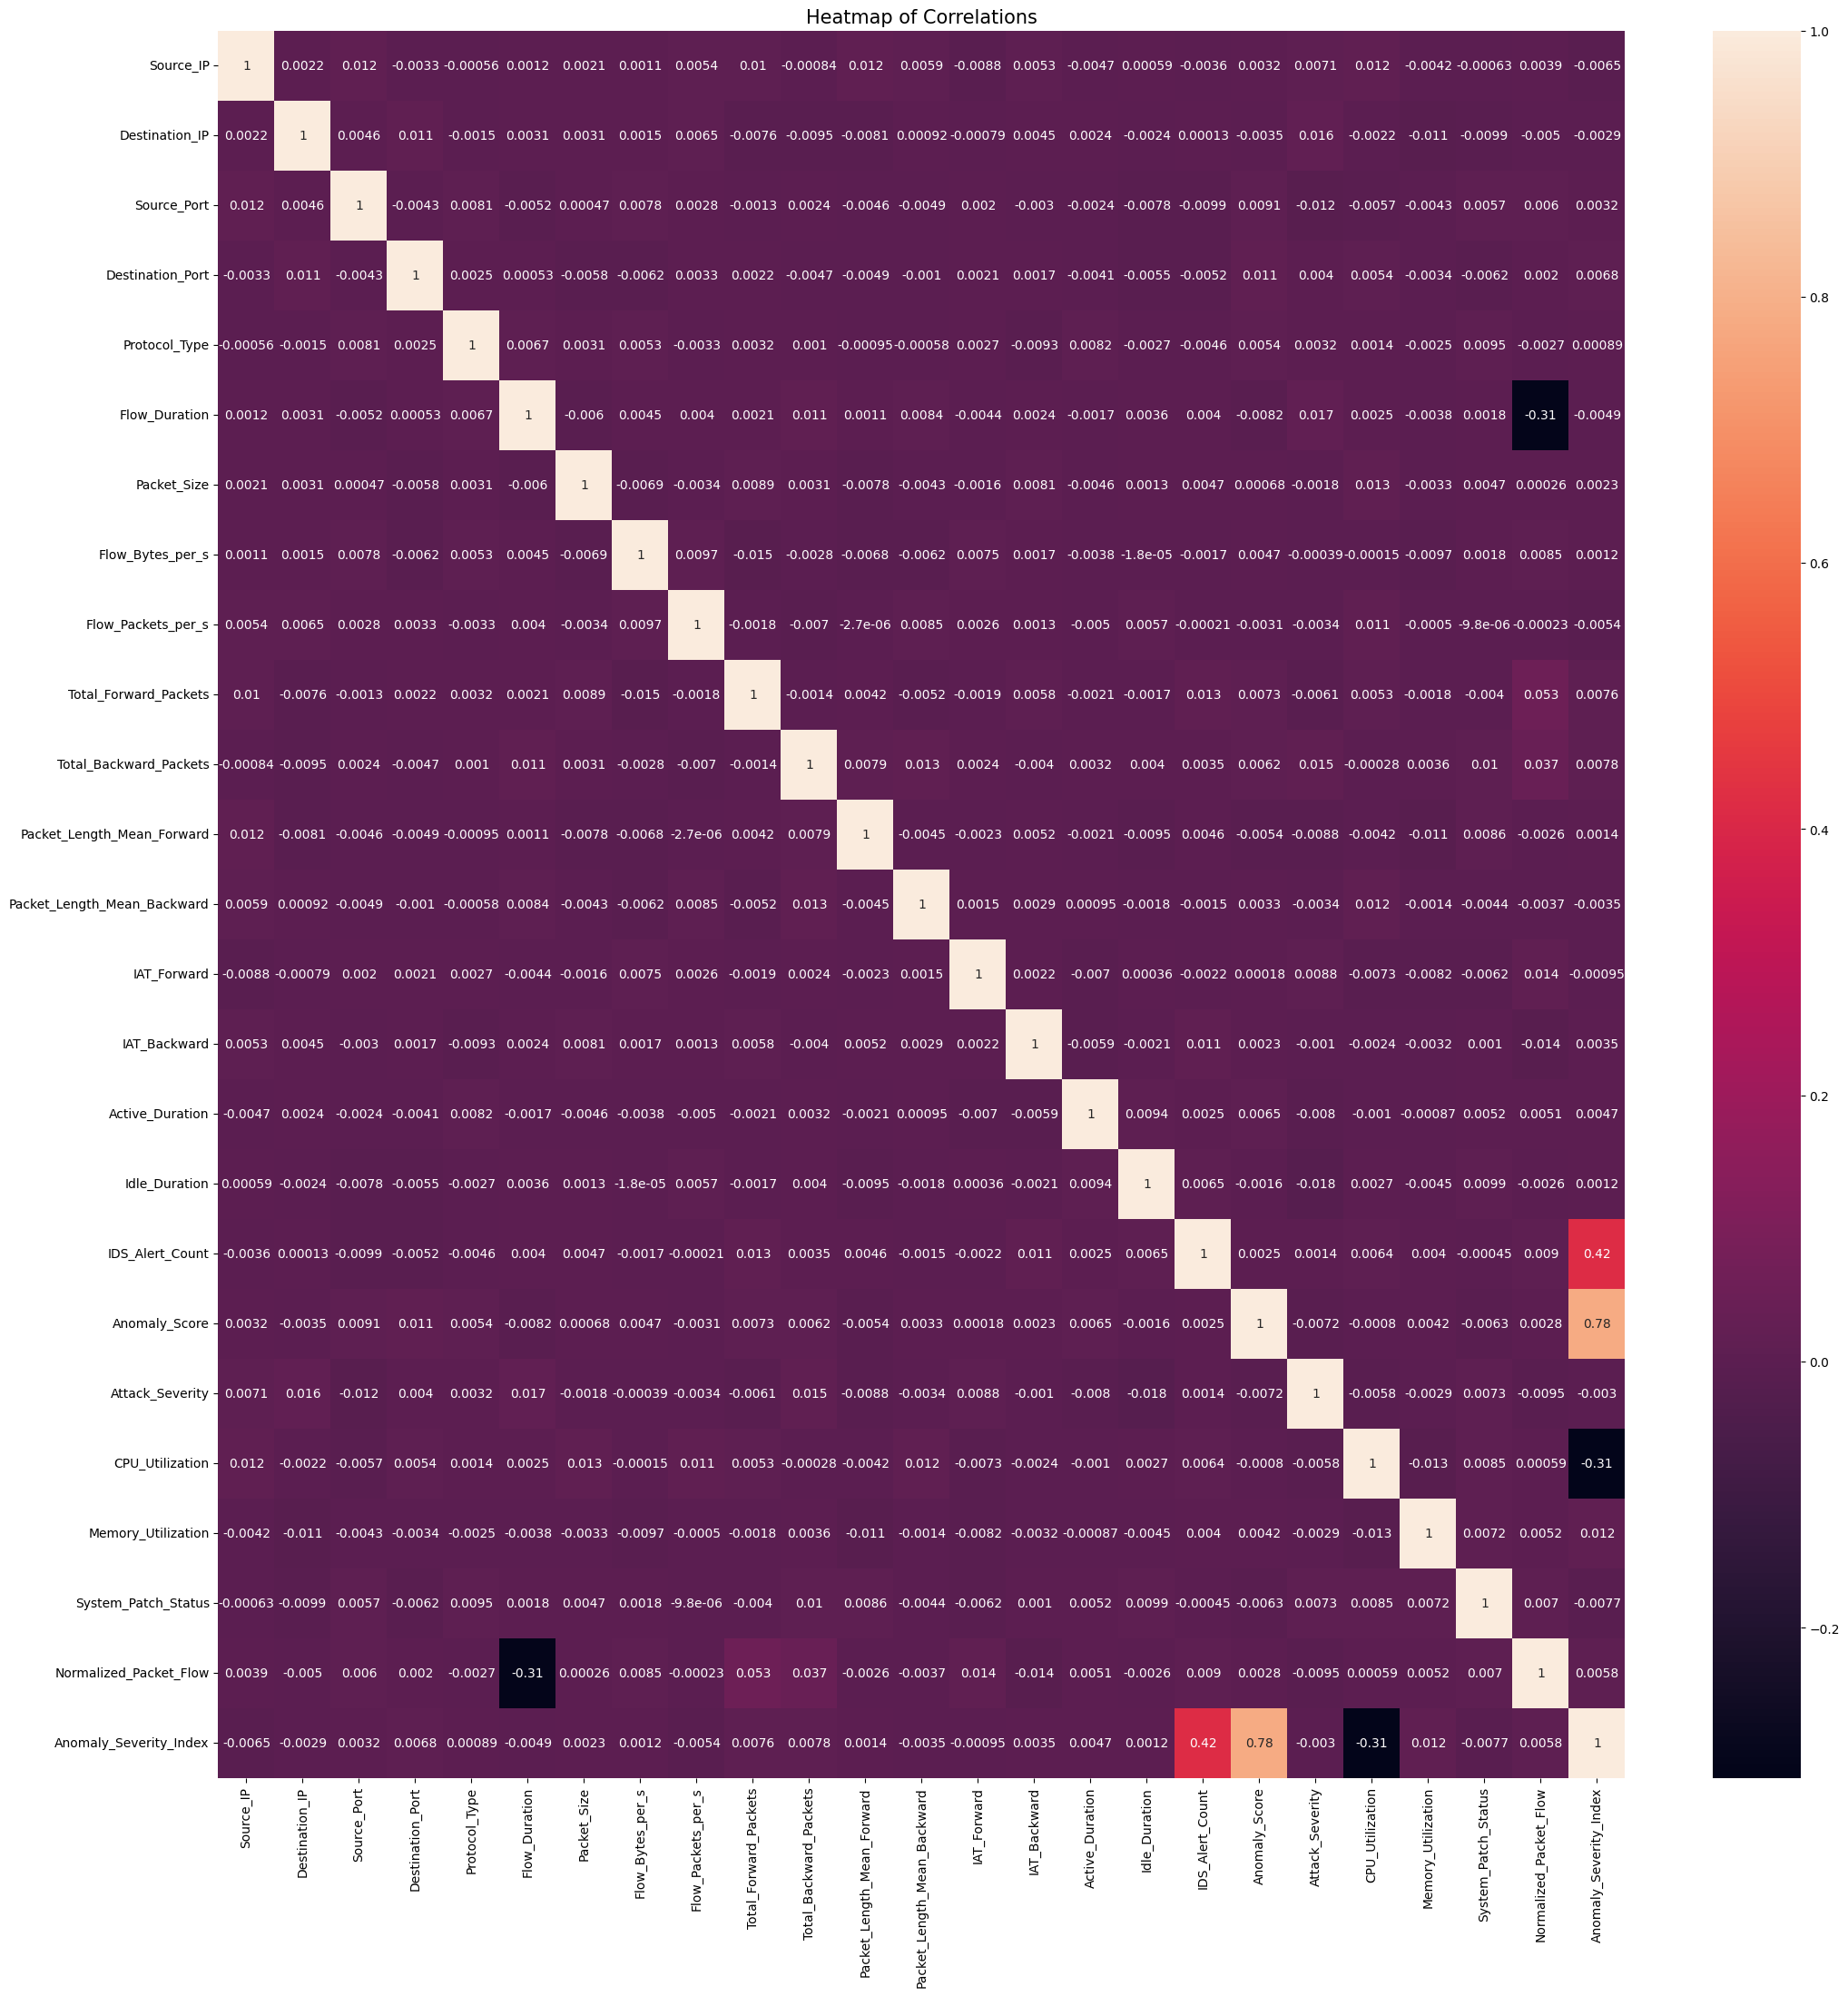

In [ ]:
plt.figure(figsize=(25,25))
sns.heatmap(df.corr(),annot=True)
plt.title('Heatmap of Correlations',fontsize=15)
plt.show()

In [ ]:
print(df.columns.tolist())

['Source_IP', 'Destination_IP', 'Source_Port', 'Destination_Port', 'Protocol_Type', 'Flow_Duration', 'Packet_Size', 'Flow_Bytes_per_s', 'Flow_Packets_per_s', 'Total_Forward_Packets', 'Total_Backward_Packets', 'Packet_Length_Mean_Forward', 'Packet_Length_Mean_Backward', 'IAT_Forward', 'IAT_Backward', 'Active_Duration', 'Idle_Duration', 'IDS_Alert_Count', 'Anomaly_Score', 'Attack_Severity', 'CPU_Utilization', 'Memory_Utilization', 'System_Patch_Status', 'Normalized_Packet_Flow', 'Anomaly_Severity_Index']


In [ ]:
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

In [ ]:
x = df.drop(columns=['Attack_Severity'])
y = df['Attack_Severity']

In [ ]:
# Import the necessary class
from sklearn.preprocessing import StandardScaler

# Normalize the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
from sklearn.decomposition import PCA
# Apply PCA to reduce dimensionality (optional but helps with large datasets)
pca = PCA(n_components=10)  # Reduce to 20 components (adjust as needed)
x_scaled_reduced = pca.fit_transform(x_scaled)

In [ ]:
x_scaled_reduced

array([[ 3.17495164,  0.5456897 , -0.94748659, ..., -1.18896402,
        -0.12551218,  0.4274884 ],
       [ 1.67245588,  0.02306612,  0.67267978, ...,  1.0994656 ,
        -1.11935348, -0.16839683],
       [-1.82189363,  1.2370507 ,  1.33528844, ..., -1.25075461,
         1.21063127,  0.5773522 ],
       ...,
       [-1.65515999,  0.027172  ,  0.82298588, ...,  1.34081484,
         0.33397176, -1.96202449],
       [-0.47772358, -0.77016257, -0.72621582, ...,  0.14924511,
         0.78760799,  0.75617862],
       [-1.60717102, -0.34004137,  0.82963491, ..., -0.46313637,
         2.01675235,  0.10020728]], shape=(297039, 10))

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming 'df' is your DataFrame

# Step 1: Select numerical columns (int64 and float64)
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Step 2: Extract numerical data
x_scaled = df[numerical_columns]

# Step 3: Scale the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_scaled)

# Step 4: Apply PCA (reduce to 10 components as an example)
pca = PCA(n_components=10)
x_scaled_reduced = pca.fit_transform(x_scaled)

# Step 5: Get feature names (from the original numerical columns) based on the PCA loadings
components = pd.DataFrame(pca.components_, columns=numerical_columns)

# Step 6: Display the original feature names contributing to each principal component
# For each component, find the feature with the highest absolute coefficient
for i, component in enumerate(components.values):
    print(f"Principal Component {i + 1}:")
    feature_contributions = pd.Series(component, index=numerical_columns)
    # Sort features by their absolute contribution to each component
    important_features = feature_contributions.abs().sort_values(ascending=False)
    print(important_features.head(10))  # Show top 10 features contributing to the component
    print("\n")

Principal Component 1:
Anomaly_Severity_Index    0.706381
Anomaly_Score             0.587635
IDS_Alert_Count           0.315854
CPU_Utilization           0.232962
Memory_Utilization        0.016383
Total_Forward_Packets     0.015186
Normalized_Packet_Flow    0.014410
System_Patch_Status       0.012497
Total_Backward_Packets    0.012490
Flow_Duration             0.012377
dtype: float64


Principal Component 2:
Normalized_Packet_Flow         0.704848
Flow_Duration                  0.689951
Total_Forward_Packets          0.114676
Attack_Severity                0.060827
Total_Backward_Packets         0.059212
IAT_Forward                    0.038503
IAT_Backward                   0.035168
Destination_IP                 0.026317
Packet_Length_Mean_Backward    0.026151
Source_Port                    0.024776
dtype: float64


Principal Component 3:
Total_Forward_Packets         0.345938
CPU_Utilization               0.334101
IDS_Alert_Count               0.312195
IAT_Forward                   

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled_reduced,y,test_size=0.20,random_state=42)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

In [ ]:
!pip install --upgrade scikit-learn xgboost

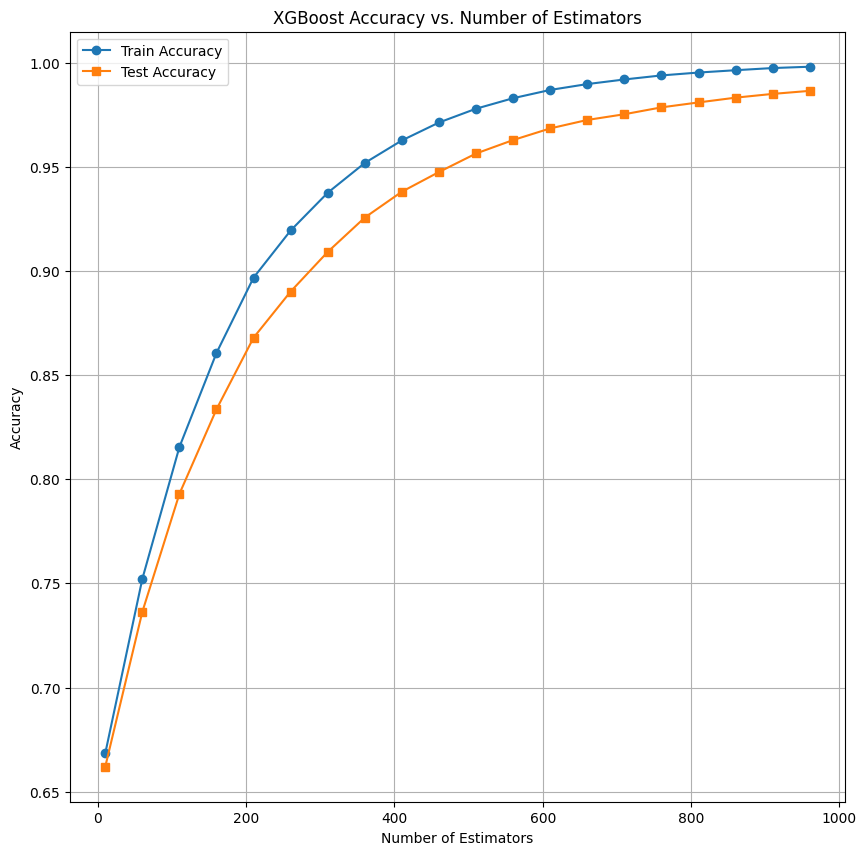

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize lists to store accuracies
train_accuracies = []
test_accuracies = []

# Range of estimators to evaluate
estimators_range = range(10, 1000, 50)  # Adjust the step or range as needed

for n_estimators in estimators_range:
    # Create an XGBoost Classifier model with varying n_estimators
    xgb_model = XGBClassifier(
        n_estimators=n_estimators,
        use_label_encoder=False,
        eval_metric='mlogloss',   # For multi-class classification
        objective='multi:softprob',  # Outputs class probabilities
        random_state=42
    )

    # Fit the model (assuming X_train, y_train are already defined)
    xgb_model.fit(x_train, y_train)

    # Predict on training and test data
    y_train_pred = xgb_model.predict(x_train)
    y_test_pred = xgb_model.predict(x_test)

    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Store accuracies
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Plotting Train and Test Accuracies
plt.figure(figsize=(10,10))
plt.plot(estimators_range, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(estimators_range, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('XGBoost Accuracy vs. Number of Estimators')
plt.legend()
plt.grid(True)
plt.show()

# Finding the best model (highest test accuracy)
best_index = test_accuracies.index(max(test_accuracies))
best_n_estimators = estimators_range[best_index]

In [ ]:
print(best_n_estimators)

960


In [ ]:
from xgboost import XGBClassifier
# Train the best model again (with the best number of estimators)
best_model = XGBClassifier(
    n_estimators=best_n_estimators,
    use_label_encoder=False,
    eval_metric='mlogloss',   # For multi-class classification
    objective='multi:softprob',  # Outputs class probabilities
    random_state=42
)
best_model.fit(x_train, y_train)

# Accessing booster for additional inspection
booster = best_model.get_booster()

In [ ]:
import joblib

# Save the trained model
joblib.dump(best_model, '/content/drive/MyDrive/cyber_model.pkl')

['/content/drive/MyDrive/cyber_model.pkl']

In [ ]:
import pickle

# Load the model, specifying the full path
with open('/content/drive/MyDrive/cyber_model.pkl', 'rb') as file:
    model = pickle.load(file)

# Now you can use the model to make predictions
predictions = model.predict(x_test)  # Assuming X_test is your input data

Evaluation & Visualization Steps:
1.Accuracy & Classification Report
2.Confusion Matrix
3.ROC-AUC Curve (if applicable)
4.Feature Importance

In [ ]:
#1. Accuracy & Classification Report
from sklearn.metrics import accuracy_score, classification_report

# Predict on test data
y_pred = best_model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9865

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     19814
           1       0.99      0.97      0.98     19902
           2       0.98      0.99      0.98     19692

    accuracy                           0.99     59408
   macro avg       0.99      0.99      0.99     59408
weighted avg       0.99      0.99      0.99     59408



In [ ]:
from sklearn.metrics import classification_report

# Print Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     19814
           1       0.99      0.97      0.98     19902
           2       0.98      0.99      0.98     19692

    accuracy                           0.99     59408
   macro avg       0.99      0.99      0.99     59408
weighted avg       0.99      0.99      0.99     59408



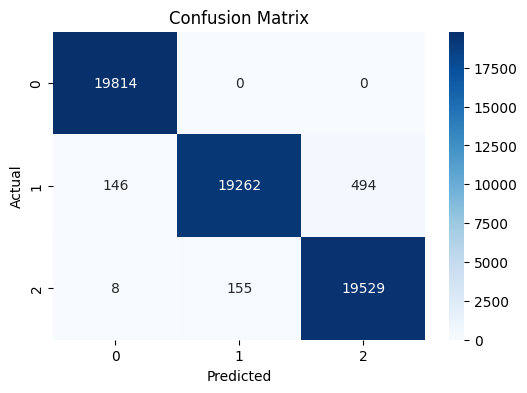

In [ ]:
#2. Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from scipy.stats import ks_2samp

# Get predicted probabilities
probs = best_model.predict_proba(x_test)[:, 1]

# KS Test
ks_stat, p_value = ks_2samp(probs[y_test == 1], probs[y_test == 0])

print(f"KS Statistic: {ks_stat}, P-value: {p_value}")

KS Statistic: 0.9915032584667394, P-value: 0.0


In [ ]:
from sklearn.metrics import log_loss

# Compute log loss
logloss = log_loss(y_test, best_model.predict_proba(x_test))
print(f"Log-Loss: {logloss}")

Log-Loss: 0.09134297004921758


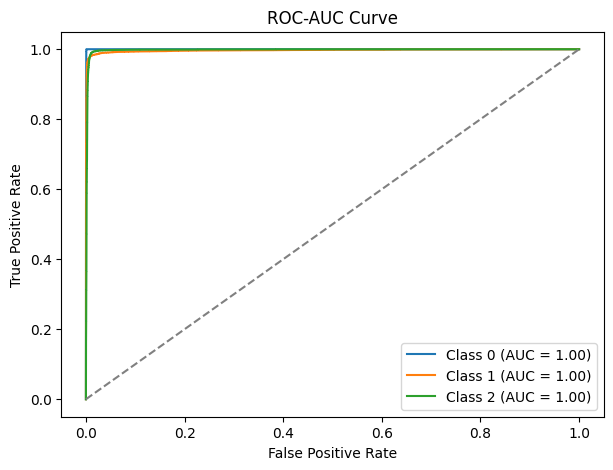

In [ ]:
#3. ROC-AUC Curve (For Multi-Class Classification)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output labels
y_test_bin = label_binarize(y_test, classes=best_model.classes_)

# Predict probabilities
y_score = best_model.predict_proba(x_test)

# Plot ROC Curve
plt.figure(figsize=(7,5))
for i, label in enumerate(best_model.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {label} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.show()

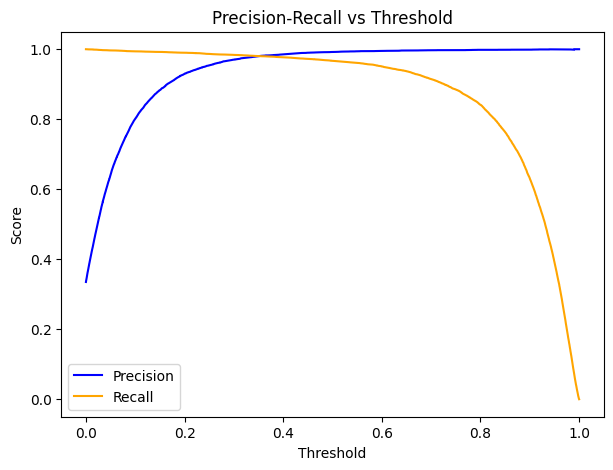

In [ ]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall curve with threshold
plt.figure(figsize=(7,5))
precisions, recalls, thresholds = precision_recall_curve(y_test_bin[:, 1], y_score[:, 1])

# Plot Precision and Recall vs Threshold
plt.plot(thresholds, precisions[:-1], label="Precision", color="blue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="orange")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

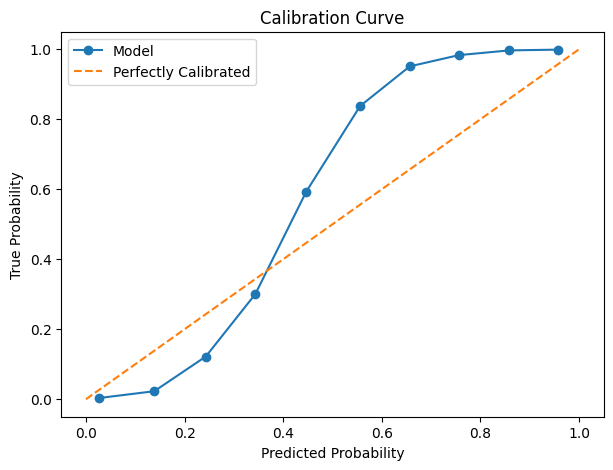

In [ ]:
from sklearn.calibration import calibration_curve

# Calibration curve for predicted probabilities
prob_true, prob_pred = calibration_curve(y_test_bin[:, 1], y_score[:, 1], n_bins=10)

# Plot Calibration Curve
plt.figure(figsize=(7,5))
plt.plot(prob_pred, prob_true, marker='o', label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly Calibrated")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()